- CLIP을 활용한 image-to-image search 구축

---

In [3]:
import os
from PIL import Image
import json
import matplotlib.pyplot as plt
import torch
from sklearn.metrics.pairwise import cosine_similarity

---
### prepare model

- zero-shot model : CLIP
- 로컬 cache에 저장된 huggingface 캐쉬 삭제
    - https://huggingface.co/docs/huggingface_hub/main/en/guides/cli
    - pip install -U "huggingface_hub[cli]" 

In [4]:
from transformers import CLIPProcessor, CLIPModel

# https://huggingface.co/

model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

/Users/igyeongseob/Develop/ai/RAG/vectorDB/vector/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1397.45it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This 

- `CLIPModel.from_pretrained`
    - 모델 checkpoint 탐색
    - 모델 weight 다운로드
    - 모델 initialization
    - 모델 meta data 로딩
- `CLIPProcessor.from_pretrained`
    - tokenizer, vocabulary 다운로드

In [5]:
dir(model)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adjust_bias',
 '_adjust_missing_and_unexpected_keys',
 '_apply',
 '_auto_class',
 '_backward_compatibility_gradient_checkpointing',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_can_compile_fullgraph',
 '_can_record_outputs',
 '_can_set_attn_implementation',
 '_can_set_experts_implementation',
 '_check_and_adjust_attn_implementation',
 '_check_and_adjust_experts_implementation',
 '_checkpoint_conversion_mapping',
 '_compiled_call_impl',
 '_copy_lm_head_original_to_resized',
 '_dispatch_accele

### data prep

In [6]:
import os
folder = '/Users/igyeongseob/.cache/kagglehub/datasets/thedownhill/art-images-drawings-painting-sculpture-engraving/versions/2//dataset/dataset_updated/training_set/drawings'

image_paths = [os.path.join(folder, i) for i in list(os.walk(folder))[0][2]]

In [7]:
image_paths[2]

'/Users/igyeongseob/.cache/kagglehub/datasets/thedownhill/art-images-drawings-painting-sculpture-engraving/versions/2//dataset/dataset_updated/training_set/drawings/i - 655.jpeg'

In [8]:
def draw_images(images, texts=None):
    n = len(images)

    if texts is None:
        texts = [''] * n

    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))

    if n == 1:
        axs = [axs]  # subplot이 단일일 때 대비

    for i in range(n):
        axs[i].imshow(images[i])
        axs[i].axis('off')
        axs[i].text(
            0.5, -0.1,
            texts[i],
            va='bottom', ha='center',
            fontsize=10,
            transform=axs[i].transAxes
        )

    plt.show()

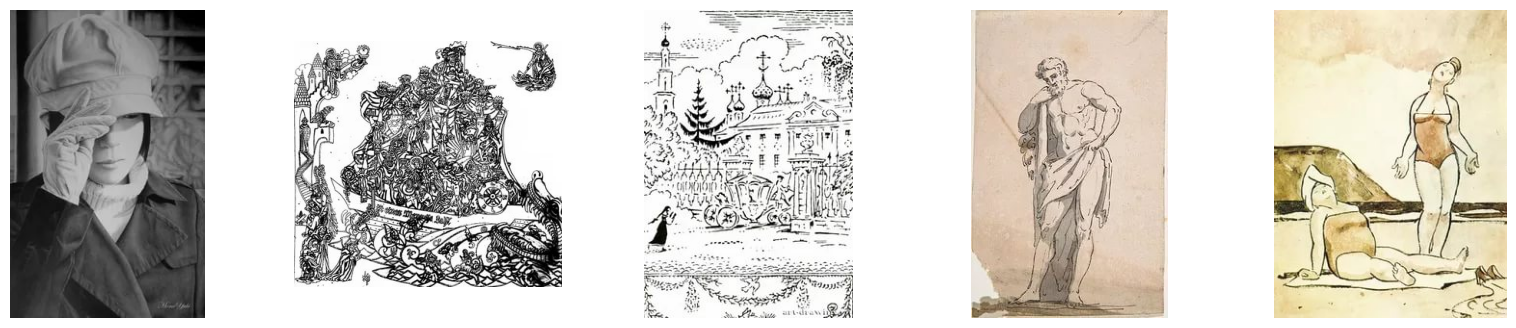

In [9]:
images = [Image.open(i) for i in image_paths[60:65]]
draw_images(images)

### Image feature extraction
- `model.get_image_features`
- low level features
    - edge, texture
- mid level features
    - low level feature를 종합
    - shapes, patterns (특정 부품 등)
- high level features
    - object type, attribute, context
    - 강아지/고양이, 누워있는/달리는, 배경 등
- Relational and Positional Features
    - 앞/뒤/위/아래
- abstract concepts
    - 텍스트와 이미지를 결합하여 이미지의 추상적인 '느낌'을 인식

In [10]:
def extract_img_features(image_path, processor, model):
    image = Image.open(image_path)
    inputs = processor(images=image, return_tensors="pt") # pytorch format
    outputs = model.get_image_features(**inputs)
    # outputs가 텐서가 아닌 경우 pooler_output 사용
    if hasattr(outputs, 'pooler_output'):
        return outputs.pooler_output.detach()
    return outputs.detach()

In [11]:
image_features = [extract_img_features(i, processor, model) for i in image_paths]

In [12]:
len(image_features)

1107

In [13]:
def search_image(query_feature, features, topk=10):
    similarities = cosine_similarity(query_feature, torch.vstack(features)).flatten()
    # sort in descending order
    sorted_indices_desc = similarities.argsort()[::-1]
    # 가장 유사도 높은 이미지는 제외 (query 이미지와 같은 이미지이기 때문)
    topk_indices = sorted_indices_desc[1:topk+1]
    # cosine similarities for the top-k indices
    topk_similarities = similarities[topk_indices]

    return topk_indices, topk_similarities

input image :


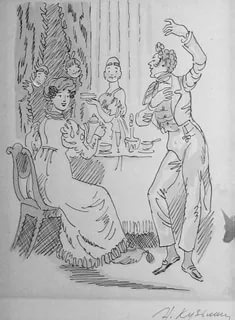

In [14]:
query_id = 5

query_feature = image_features[query_id]
most_similar_idx, distance = search_image(query_feature, image_features)

print("input image :")
Image.open(image_paths[query_id])

In [15]:
# 이미지 읽어오기
similar_images = [Image.open(image_paths[i]) for i in most_similar_idx]

In [16]:
similar_images

[<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=374x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=213x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=229x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=206x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=314x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=200x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=228x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=212x320>,
 <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=219x320>]

##### search_image 함수에서 상위 10개 유사 이미지 반환 (topk=10)

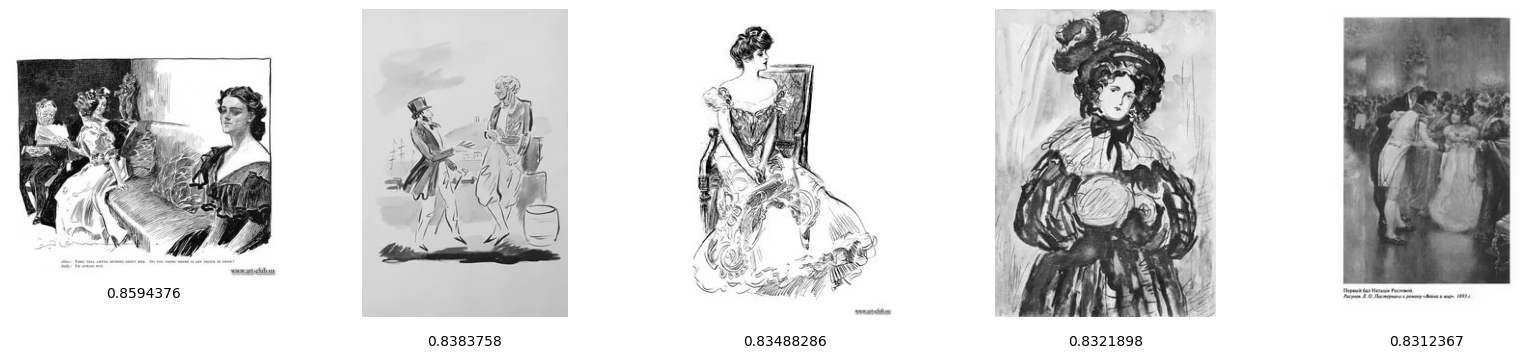

In [17]:
#  유사도 1~5위 이미지 출력
draw_images(similar_images[:5], distance[:5])

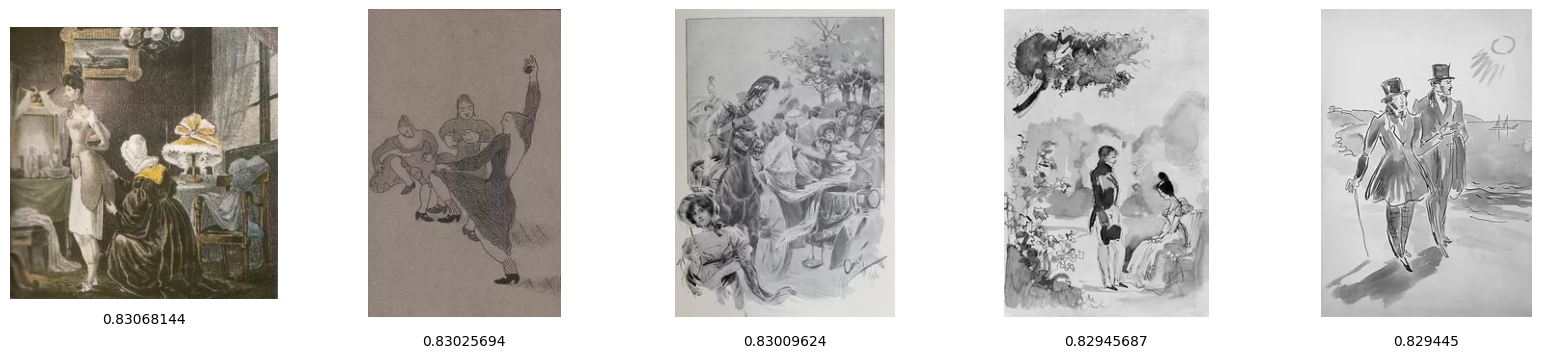

In [18]:
# 유사도 6~10위 이미지 출력
draw_images(similar_images[5:], distance[5:])

### 한계점
- 이미지 내부의 세부적인 디테일을 고려하지 못함

### => 다음 시간에는... Image preprocessing을 통한 detailed search
- Document를 문단/문장으로 나누는 것과 유사
- 이미지에 들어있는 다양한 정보들을 "chunking"하여 개별적으로 저장

--END--